# 06. Year-to-year balance attribution

Attribute every annual change in the General Government balance to changes in the three subsectors, and distinguish the level of a balance from its contribution to an annual movement.

**Reads**

- `outputs/tables/balance_change_attribution.csv`

**Writes**

- Nothing. The attribution table is persisted by the pipeline.

**Method reference:** `METHODOLOGY.md` section 6

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. An exact decomposition

$$\Delta B^{GG}_t = \Delta B^{C}_t + \Delta B^{RL}_t + \Delta B^{SSF}_t.$$

This holds by construction, so the table is a reallocation of an observed change
rather than an estimate.

In [2]:
attribution = pd.read_csv(TABLES / 'balance_change_attribution.csv')
change_columns = [
    'year',
    'aggregate_change_m_eur',
    'central_change_m_eur',
    'regional_local_change_m_eur',
    'ssf_change_m_eur',
    'change_closure_error_m_eur',
]
display(attribution[change_columns].tail(12).round(1))

,year,aggregate_change_m_eur,central_change_m_eur,regional_local_change_m_eur,ssf_change_m_eur,change_closure_error_m_eur
36,2014,-3854.0,-4659.0,346.0,460.0,-1.0
37,2015,4726.0,4283.0,121.0,321.0,1.0
38,2016,4404.0,3876.0,87.0,441.0,0.0
39,2017,-2248.0,-2405.0,-515.0,673.0,-1.0
40,2018,4997.0,5053.0,151.0,-208.0,1.0
41,2019,1122.0,76.0,105.0,940.0,1.0
42,2020,-11813.0,-10224.0,-811.0,-777.0,-1.0
43,2021,5447.0,5570.0,-394.0,270.0,1.0
44,2022,5360.0,3019.0,510.0,1831.0,0.0
45,2023,3787.0,2519.0,-152.0,1421.0,-1.0


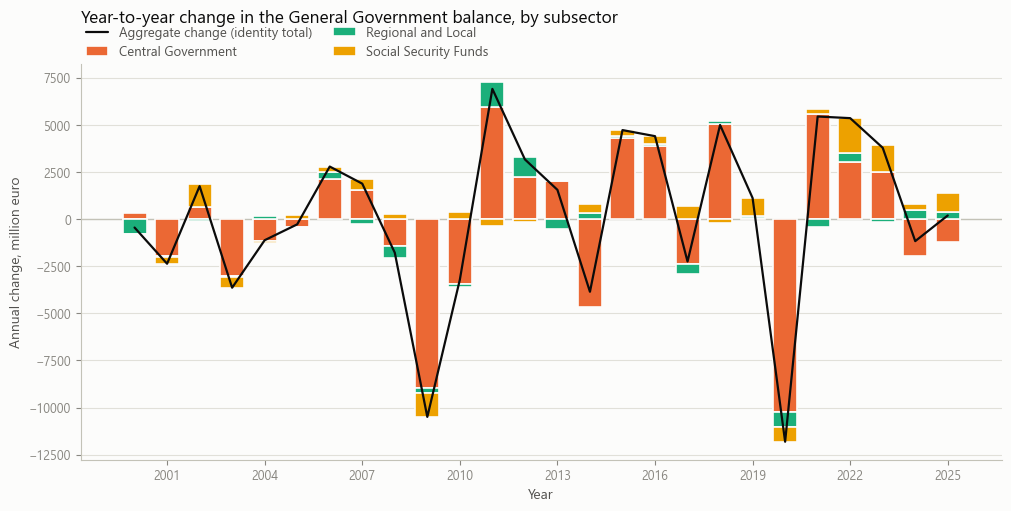

In [3]:
figure = figures.balance_change_attribution(attribution)

## 2. The largest annual movements

Shares are expressed against the absolute aggregate change, so a share above one
means a subsector moved further than the aggregate and was partly offset by
another subsector. A negative share means the subsector moved against the
aggregate.

In [4]:
share_columns = [
    'year',
    'aggregate_change_m_eur',
    'central_change_share_abs_aggregate_change',
    'regional_local_change_share_abs_aggregate_change',
    'ssf_change_share_abs_aggregate_change',
]
largest = attribution.reindex(attribution['aggregate_change_m_eur'].abs().sort_values(ascending=False).index)
display(largest[share_columns].head(10).round(3))

,year,aggregate_change_m_eur,central_change_share_abs_aggregate_change,regional_local_change_share_abs_aggregate_change,ssf_change_share_abs_aggregate_change
42,2020,-11813.0,-0.865,-0.069,-0.066
31,2009,-10496.0,-0.852,-0.028,-0.121
33,2011,6913.0,0.859,0.194,-0.053
43,2021,5447.0,1.023,-0.072,0.050
44,2022,5360.0,0.563,0.095,0.342
40,2018,4997.0,1.011,0.030,-0.042
37,2015,4726.0,0.906,0.026,0.068
38,2016,4404.0,0.880,0.020,0.100
36,2014,-3854.0,-1.209,0.090,0.119
45,2023,3787.0,0.665,-0.040,0.375


## 3. Closure check

In [5]:
print('max |change-identity residual| (M EUR):', round(float(attribution['change_closure_error_m_eur'].abs().max()), 6))
print('observations:', len(attribution), 'covering', int(attribution['year'].min()), 'to', int(attribution['year'].max()))

max |change-identity residual| (M EUR): 1.0
observations: 48 covering 1978 to 2025


## Interpretation limits

1. **Contribution is not causation.** A subsector accounting for most of an
   annual improvement has not been shown to have produced it.
2. The 1994-to-1995 change crosses the **statistical splice** and mixes a
   vintage revision with an economic movement.
3. Attribution operates on **balances only**. Whether a movement came from
   revenue or expenditure is the subject of notebook 05.

---

[Previous: 05. Revenue and expenditure decomposition](05_revenue_expenditure.ipynb) | [Next: 07. Balance persistence and sign transitions](07_persistence.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```